In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications import EfficientNetV2S #  UPGRADED BACKBONE

2026-06-13 05:07:25.801129: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781327246.042081      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781327246.109527      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781327246.650710      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781327246.650762      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781327246.650766      58 computation_placer.cc:177] computation placer alr

In [2]:
# --- CONFIGURATION ---
CSV_PATH = "/kaggle/input/datasets/sauravmane9440/skin-cancer-dataset/final_dataset/metadata.csv" 
DATASET_BASE = "/kaggle/input/datasets/sauravmane9440/skin-cancer-dataset/final_dataset"
IMG_SIZE = 256 # Optimized for EfficientNet
BATCH_SIZE = 16 
EPOCHS = 50 # Finishing by 3 PM

In [3]:
# --- 1. DATA PREP ---
df = pd.read_csv(CSV_PATH)

df['img_path'] = df['location'].apply(
    lambda x: os.path.join(DATASET_BASE, x)
)

df['mask_path'] = df['location'].apply(
    lambda x: os.path.join(DATASET_BASE, "mask", x)
)

classes = sorted(df['dx'].unique())

class_to_idx = {
    cls: idx
    for idx, cls in enumerate(classes)
}

df['label_idx'] = df['dx'].map(class_to_idx)

# 70% Train
# 15% Validation
# 15% Test

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label_idx'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label_idx'],
    random_state=42
)

print("Train Samples :", len(train_df))
print("Validation Samples :", len(val_df))
print("Test Samples :", len(test_df))

Train Samples : 14136
Validation Samples : 3029
Test Samples : 3030


In [4]:
# --- 2. BALANCED GENERATOR ---
class BalancedHybridGenerator(Sequence):
    def __init__(self, dataframe, batch_size, augment=False):
        self.batch_size = batch_size
        self.augment = augment
        self.classes = dataframe['label_idx'].unique()
        self.class_groups = {
            cls: dataframe[dataframe['label_idx'] == cls][['img_path', 'mask_path']].values 
            for cls in self.classes
        }
        self.df_len = len(dataframe)

    def __len__(self):
        return self.df_len // self.batch_size

    def __getitem__(self, idx):
        X, Y = [], []
        for _ in range(self.batch_size):
            chosen_cls = np.random.choice(self.classes)
            paths = self.class_groups[chosen_cls]
            img_p, mask_p = paths[np.random.randint(len(paths))]
            
            img = cv2.imread(img_p)
            mask = cv2.imread(mask_p, 0)
            
            if img is None: img = np.zeros((IMG_SIZE, IMG_SIZE, 3))
            else: img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            if mask is None: mask = np.zeros((IMG_SIZE, IMG_SIZE))
            else: mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

            if self.augment:
                if np.random.rand() > 0.5: img = cv2.flip(img, 1); mask = cv2.flip(mask, 1)
                if np.random.rand() > 0.5:
                    angle = np.random.randint(-15, 15)
                    M = cv2.getRotationMatrix2D((IMG_SIZE//2, IMG_SIZE//2), angle, 1.0)
                    img = cv2.warpAffine(img, M, (IMG_SIZE, IMG_SIZE))
                    mask = cv2.warpAffine(mask, M, (IMG_SIZE, IMG_SIZE))

            X.append(np.concatenate([img/255.0, np.expand_dims(mask/255.0, -1)], axis=-1))
            Y.append(to_categorical(chosen_cls, num_classes=len(classes)))
        return np.array(X), np.array(Y)

In [5]:
# --- 3. ARCHITECTURE (EfficientNetV2 + Transformer) ---
def transformer_block(x):
    attn = MultiHeadAttention(num_heads=8, key_dim=64)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)
    ffn = Dense(x.shape[-1]*2, activation='gelu')(x)
    ffn = Dense(x.shape[-1])(ffn)
    x = Add()([x, ffn])
    x = LayerNormalization()(x)
    return x

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 4))
adapter = Conv2D(3, (1,1))(inputs) 

base = EfficientNetV2S(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = True # Unfreeze for medical fine-tuning

x = base(adapter) 
shape = x.shape
x = Reshape((shape[1] * shape[2], shape[3]))(x) 
x = transformer_block(x)
x = transformer_block(x)

x = GlobalAveragePooling1D()(x)
x = Dropout(0.4)(x) 
outputs = Dense(len(classes), activation='softmax')(x)
model = Model(inputs, outputs)

I0000 00:00:1781327261.077312      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# --- 4. COMPILATION ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=2.0, label_smoothing=0.1),
    metrics=['accuracy']
)

In [ ]:
# --- 5. SECURE SAVING CALLBACKS ---
callbacks = [
    # 1. SAVE THE BEST MODEL ONLY
    ModelCheckpoint(
        '/kaggle/working/best_skin_disease_model.keras', 
        monitor='val_accuracy', 
        save_best_only=True, 
        mode='max', 
        verbose=1
    ),
    
    # 2. REDUCE LEARNING RATE 
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    
    # 3. EARLY STOPPING (Stops if the model stops improving)
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
]

In [8]:
# --- 6. EXECUTION ---

train_gen = BalancedHybridGenerator(
    train_df,
    BATCH_SIZE,
    augment=True
)

val_gen = BalancedHybridGenerator(
    val_df,
    BATCH_SIZE,
    augment=False
)

test_gen = BalancedHybridGenerator(
    test_df,
    BATCH_SIZE,
    augment=False
)

print("Starting training...")

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Starting training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1781327352.646030     122 service.cc:152] XLA service 0x7b897c002900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781327352.646074     122 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781327368.790804     122 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-13 05:09:51.993647: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-13 05:09:52.184349: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-13 05:09:52.631105: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

883/883 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.5711 - loss: 0.3034
Epoch 1: val_accuracy improved from None to 0.76290, saving model to /kaggle/working/best_skin_disease_model.keras

Epoch 1: finished saving model to /kaggle/working/best_skin_disease_model.keras
883/883 ━━━━━━━━━━━━━━━━━━━━ 477s 330ms/step - accuracy: 0.6852 - loss: 0.2388 - val_accuracy: 0.7629 - val_loss: 0.1900 - learning_rate: 1.0000e-04
Epoch 2/50
883/883 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.8079 - loss: 0.1711
Epoch 2: val_accuracy improved from 0.76290 to 0.82143, saving model to /kaggle/working/best_skin_disease_model.keras

Epoch 2: finished saving model to /kaggle/working/best_skin_disease_model.keras
883/883 ━━━━━━━━━━━━━━━━━━━━ 235s 266ms/step - accuracy: 0.8264 - loss: 0.1627 - val_accuracy: 0.8214 - val_loss: 0.1650 - learning_rate: 1.0000e-04
Epoch 3/50
883/883 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.8633 - loss: 0.1440
Epoch 3: val_accuracy improved from 0.82143 to 0.83201

In [9]:
# --- 7. FINAL SAVE ---
model.save('/kaggle/working/final_completed_model.keras')
print("Model saved to /kaggle/working/final_completed_model.keras")

Model saved to /kaggle/working/final_completed_model.keras


Loading best model...
Running Final Test Evaluation...

FINAL TEST ACCURACY : 86.27%

Classification Report:

              precision    recall  f1-score   support

    abrasion       1.00      1.00      1.00        24
       akiec       0.77      0.78      0.78       274
         bcc       0.83      0.91      0.87       576
         bkl       0.68      0.76      0.72       165
      bruise       1.00      1.00      1.00        36
        burn       1.00      1.00      1.00        20
         cut       1.00      1.00      1.00        15
          df       1.00      0.71      0.83        17
         mel       0.88      0.83      0.85       846
      normal       1.00      1.00      1.00        30
          nv       0.91      0.88      0.90      1006
        vasc       0.87      0.95      0.91        21

    accuracy                           0.86      3030
   macro avg       0.91      0.90      0.90      3030
weighted avg       0.87      0.86      0.86      3030



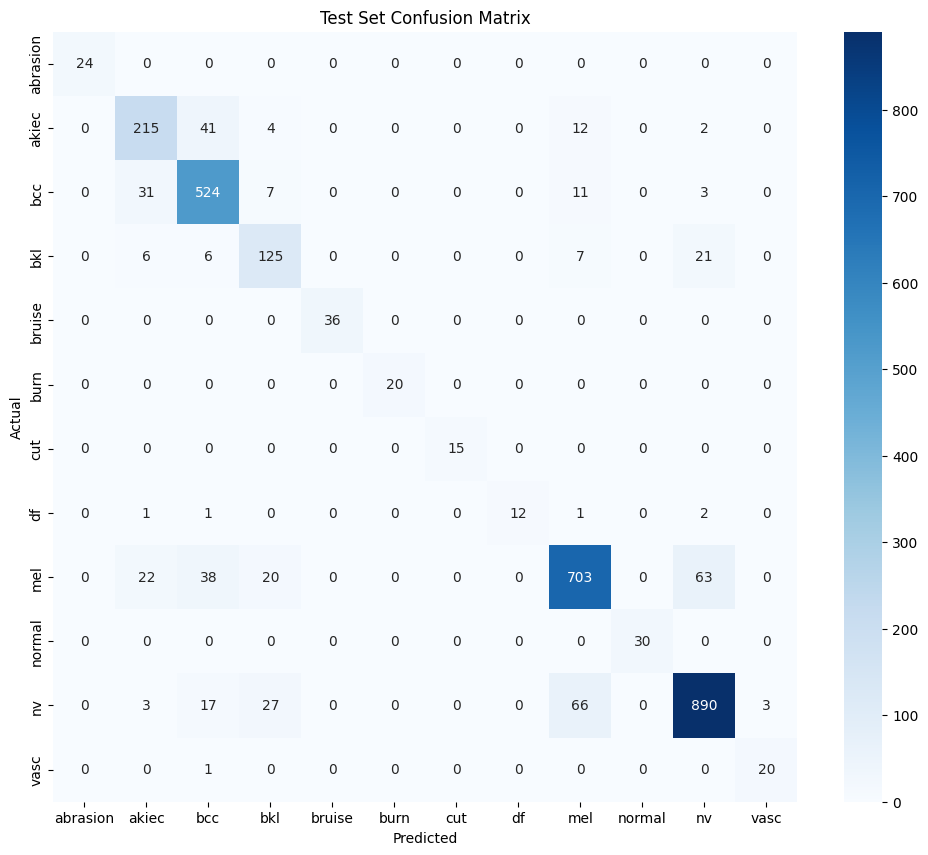

In [11]:
import tensorflow as tf
import numpy as np
import cv2

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

print("Loading best model...")

best_model = tf.keras.models.load_model(
    "/kaggle/working/best_skin_disease_model.keras"
)

print("Running Final Test Evaluation...")

all_preds = []
all_true = []

for _, row in test_df.iterrows():

    # Load image
    img = cv2.imread(row["img_path"])

    # Load mask
    mask = cv2.imread(
        row["mask_path"],
        0
    )

    if img is None or mask is None:
        continue

    # Resize
    img = cv2.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )

    mask = cv2.resize(
        mask,
        (IMG_SIZE, IMG_SIZE)
    )

    # Normalize
    img = img.astype(np.float32) / 255.0

    mask = mask.astype(np.float32) / 255.0

    mask = np.expand_dims(
        mask,
        axis=-1
    )

    # Create 4-channel input
    x = np.concatenate(
        [img, mask],
        axis=-1
    )

    x = np.expand_dims(
        x,
        axis=0
    )

    # Prediction
    probs = best_model.predict(
        x,
        verbose=0
    )[0]

    pred_class = np.argmax(probs)

    all_preds.append(
        pred_class
    )

    all_true.append(
        row["label_idx"]
    )

all_preds = np.array(all_preds)
all_true = np.array(all_true)

# Test Accuracy
test_acc = np.mean(
    all_preds == all_true
)

print("\n================================")
print(
    f"FINAL TEST ACCURACY : {test_acc*100:.2f}%"
)
print("================================\n")

# Classification Report
print("Classification Report:\n")

print(
    classification_report(
        all_true,
        all_preds,
        target_names=classes
    )
)

# Confusion Matrix
cm = confusion_matrix(
    all_true,
    all_preds
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title(
    "Test Set Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()